<a href="https://colab.research.google.com/github/Alister44/DTA_2026_DE/blob/main/sales_store_analysis/sales_store_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Verkaufsanalyse eines Geschäfts


# Eingangsdatensatz (Daten)


In [ ]:
# Führe diesen Block aus, um den Datensatz zu erhalten
import pandas as pd
import numpy as np

np.random.seed(42)
n = 300

categories = ['Molkereiprodukte', 'Brot und Backwaren', 'Fleisch und Fisch', 'Obst und Gemüse', 'Getränke']
products = {
    'Molkereiprodukte':   ['Milch 1L', 'Kefir 0.5L', 'Quark', 'Butter', 'Joghurt'],
    'Brot und Backwaren': ['Weißbrot', 'Baguette', 'Brötchen', 'Roggenbrot', 'Croissant'],
    'Fleisch und Fisch':  ['Hähnchenfilet', 'Schweinefleisch', 'Wurst', 'Seelachs', 'Würstchen'],
    'Obst und Gemüse':   ['Kartoffeln', 'Karotten', 'Äpfel', 'Bananen', 'Tomaten'],
    'Getränke':          ['Wasser 1.5L', 'Orangensaft', 'Tee', 'Gemahlener Kaffee', 'Limonade'],
}
prices = {
    'Milch 1L': 1.15, 'Kefir 0.5L': 1.20, 'Quark': 1.50, 'Butter': 2.30, 'Joghurt': 0.85,
    'Weißbrot': 1.80, 'Baguette': 1.50, 'Brötchen': 0.40, 'Roggenbrot': 2.20, 'Croissant': 1.10,
    'Hähnchenfilet': 6.50, 'Schweinefleisch': 8.90, 'Wurst': 4.50, 'Seelachs': 5.20, 'Würstchen': 3.80,
    'Kartoffeln': 1.20, 'Karotten': 0.90, 'Äpfel': 2.20, 'Bananen': 1.80, 'Tomaten': 2.90,
    'Wasser 1.5L': 0.65, 'Orangensaft': 2.50, 'Tee': 3.20, 'Gemahlener Kaffee': 5.90, 'Limonade': 1.40,
}

chosen_cats = np.random.choice(categories, n, p=[0.25, 0.20, 0.20, 0.20, 0.15])
chosen_products = [np.random.choice(products[c]) for c in chosen_cats]

df_origin = pd.DataFrame({
    'transaction_id': range(1001, 1001 + n),
    'date':           pd.to_datetime(
                          np.random.choice(pd.date_range('2024-03-01', '2024-03-31'), n)
                      ),
    'hour':           np.random.choice(range(8, 21), n, p=[0.04,0.06,0.08,0.10,0.12,0.12,0.11,0.10,0.09,0.08,0.06,0.04,0.00]),
    'category':       chosen_cats,
    'product':        chosen_products,
    'quantity':       np.random.randint(1, 6, n),
    'price_eur':      [prices[p] for p in chosen_products],
    'customer_age':   np.random.randint(18, 70, n),
    'payment':        np.random.choice(['Bargeld', 'Karte', 'Telefon'], n, p=[0.35, 0.50, 0.15]),
})




In [ ]:
df = df_origin.copy()
df

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment
0,1001,2024-03-17,17,Хліб та випічка,Круасан,4,18,28,Готівка
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка
2,1003,2024-03-01,18,Овочі та фрукти,Яблука,1,45,43,Картка
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка
...,...,...,...,...,...,...,...,...,...
295,1296,2024-03-08,10,М'ясо та риба,Сосиски,4,98,48,Готівка
296,1297,2024-03-05,13,Овочі та фрукти,Морква,5,15,28,Телефон
297,1298,2024-03-04,11,Молочне,Молоко 1л,3,38,27,Картка
298,1299,2024-03-24,14,М'ясо та риба,Ковбаса,1,145,20,Готівка


Block 1 - Erster Blick auf die Daten


Gib die ersten 7 Zeilen des DataFrames aus.


In [ ]:
df.head(7)

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment
0,1001,2024-03-17,17,Хліб та випічка,Круасан,4,18,28,Готівка
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка
2,1003,2024-03-01,18,Овочі та фрукти,Яблука,1,45,43,Картка
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка
5,1006,2024-03-03,13,Молочне,Кефір 0.5л,3,22,51,Картка
6,1007,2024-03-31,15,Молочне,Масло вершкове,2,95,46,Телефон


In [ ]:
print(df.head(7))

   transaction_id       date  hour         category         product  quantity  \
0            1001 2024-03-17    17  Хліб та випічка         Круасан         4   
1            1002 2024-03-13    14            Напої     Кава мелена         3   
2            1003 2024-03-01    18  Овочі та фрукти          Яблука         1   
3            1004 2024-03-02     8    М'ясо та риба        Риба хек         3   
4            1005 2024-03-09    19          Молочне          Йогурт         5   
5            1006 2024-03-03    13          Молочне      Кефір 0.5л         3   
6            1007 2024-03-31    15          Молочне  Масло вершкове         2   

   price_uah  customer_age  payment  
0         18            28  Готівка  
1        155            40   Картка  
2         45            43   Картка  
3        120            51  Готівка  
4         30            63   Картка  
5         22            51   Картка  
6         95            46  Телефон  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  300 non-null    int64         
 1   date            300 non-null    datetime64[ns]
 2   hour            300 non-null    int64         
 3   category        300 non-null    object        
 4   product         300 non-null    object        
 5   quantity        300 non-null    int64         
 6   price_uah       300 non-null    int64         
 7   customer_age    300 non-null    int64         
 8   payment         300 non-null    object        
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 21.2+ KB


In [ ]:
df['total_eur'] = df.quantity * df.price_eur

Finde die Größe der Tabelle heraus (Zeilen × Spalten).


In [ ]:
print(f"Size: {df.shape[0]} - rows,{df.shape[1]} -columns ")

Size: 300 - rows,10 -columns 


Gib die Datentypen jeder Spalte aus.


In [ ]:
print("Data types: ")
display(df.dtypes)

Data types: 


,0
transaction_id,int64
date,datetime64[ns]
hour,int64
category,object
product,object
quantity,int64
price_uah,int64
customer_age,int64
payment,object
total_uah,int64


Prüfe, ob es fehlende Werte gibt.


In [ ]:
df.isna()

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
295,False,False,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False,False


In [ ]:
print(f"Fehlende Werte pro Spalte {df.isnull().sum()}")


Пропущені значення по стовпцям transaction_id    0
date              0
hour              0
category          0
product           0
quantity          0
price_uah         0
customer_age      0
payment           0
total_uah         0
dtype: int64


Gib die grundlegende Statistik (describe) für die numerischen Spalten aus.


In [ ]:
print("Statistik: \n")
df.describe().round(2)


Статистика: 



,transaction_id,date,hour,quantity,price_uah,customer_age,total_uah
count,300.00,300,300.00,300.00,300.00,300.0,300.00
mean,1150.50,2024-03-16 02:14:24,13.72,2.97,63.45,43.0,186.97
min,1001.00,2024-03-01 00:00:00,8.00,1.00,12.00,18.0,12.00
25%,1075.75,2024-03-08 00:00:00,12.00,2.00,22.00,31.0,60.00
50%,1150.50,2024-03-16 12:00:00,14.00,3.00,38.00,42.5,120.00
75%,1225.25,2024-03-24 00:00:00,16.00,4.00,95.75,55.0,256.25
max,1300.00,2024-03-31 00:00:00,19.00,5.00,210.00,69.0,840.00
std,86.75,NaN,2.74,1.44,51.68,14.6,180.27


In [ ]:
s = [1, 7, 9, 10, 12, 15, 20]
mean = sum(s)/len(s)
mean
s = [1, 1, 1, 1, 1, 1, 1000]
mean = sum(s)/len(s)
mean
# std -> 143.71 - 1 = 142.71
mediana = 1

**Schlussfolgerung**  
Der Datensatz enthält Informationen zu 300 Transaktionen  
Durchschnittlicher Bonbetrag - 7.55 €  
Minimaler Bon - 0.40 €  
Maximaler Bon - 35.60 €


# Block 2 - Filterung und Auswahl


Wähle alle Käufe der Kategorie „Fleisch und Fisch" aus.


In [ ]:
# Aufgabe:
df[df["category"] == "Fleisch und Fisch"].head()


,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка,360
8,1009,2024-03-21,15,М'ясо та риба,Ковбаса,2,145,34,Картка,290
17,1018,2024-03-06,14,М'ясо та риба,Куряче філе,3,165,69,Картка,495
20,1021,2024-03-23,9,М'ясо та риба,Куряче філе,3,165,64,Телефон,495
24,1025,2024-03-10,14,М'ясо та риба,Свинина,4,210,28,Картка,840


In [ ]:
meat_fish = df[df["category"] == "Fleisch und Fisch"]
print(f"In der Kategorie Fleisch und Fisch gibt es {len(meat_fish)} Transaktionen")


У категорії м'ясо та риба 61 транзакцій


Finde Transaktionen, bei denen der Betrag (total_eur) 20 € übersteigt.



In [ ]:
big = df[df['total_eur'] > 20]
print(f"Käufe über 20 € - {len(big)}")
print(big[['product','quantity','total_eur']].head())


Покупки більше 500 - 17
        product  quantity  total_uah
24      Свинина         4        840
28  Куряче філе         4        660
81      Ковбаса         4        580
89     Риба хек         5        600
93      Свинина         3        630


In [ ]:
big.category.unique()

array(["М'ясо та риба", 'Напої'], dtype=object)

In [ ]:
for cat in big.category.unique():
    print(f"{cat} - {big['category'].count()}")

М'ясо та риба - 17
Напої - 17


In [ ]:
# Prozentsatz der großen Käufe
pct_big = len(big) / len(df) * 100
round(pct_big,2)
print(f"Anteil der Käufe > 20 €: {pct_big:.1f}")


Частка покупок > 500: 5.7


Wähle Käufe aus, die mit Karte bezahlt wurden (payment == 'Karte'), mit einer Menge über 2 Einheiten.


In [ ]:
card_mult = df[(df['payment'] == 'Karte') & (df['quantity'] > 2)]
print("Karte + Menge > 2: ",len(card_mult))


Картка + кількість > 2:  92


Finde alle Käufe von Kunden unter 25 Jahren.


In [ ]:
young = df[df['customer_age'] < 25]
print(f"Kunden unter 25 Jahren: {len(young)}")


Покупців до 25 років: 36


Wie viele eindeutige Produkte gibt es im Datensatz?


In [ ]:
n_unique = df['product'].nunique() #Anzahl der eindeutigen Produkte
n_unique


25

In [ ]:
pr_unique = df['product'].unique() #Liste der eindeutigen Produkte
pr_unique


array([np.str_('Круасан'), np.str_('Кава мелена'), np.str_('Яблука'),
       np.str_('Риба хек'), np.str_('Йогурт'), np.str_('Кефір 0.5л'),
       np.str_('Масло вершкове'), np.str_('Сік апельсиновий'),
       np.str_('Ковбаса'), np.str_('Картопля'),
       np.str_('Сир кисломолочний'), np.str_('Морква'),
       np.str_('Куряче філе'), np.str_('Хліб житній'), np.str_('Батон'),
       np.str_('Хліб білий'), np.str_('Свинина'), np.str_('Сосиски'),
       np.str_('Молоко 1л'), np.str_('Помідори'), np.str_('Лимонад'),
       np.str_('Булочка'), np.str_('Банани'), np.str_('Вода 1.5л'),
       np.str_('Чай')], dtype=object)

## Schlussfolgerung  
Etwa die Hälfte der Käufe wird mit Karte bezahlt, davon hat ein Drittel mehr als 2 Produkte im Bon.  
6,7% der Transaktionen überschreiten einen Bon von 20 €, meistens in der Kategorie „Fleisch und Fisch"  


12% der Kunden sind unter 25 Jahren


# Block 3 - Gruppierung und Aggregation


Berechne den Gesamtumsatz für jede Kategorie. Sortiere absteigend.


In [ ]:
revenue_by_cat = df.groupby('category')['total_eur'].sum().sort_values(ascending=False)
revenue_by_cat


,total_uah
category,
М'ясо та риба,25223
Напої,10389
Молочне,10075
Овочі та фрукти,6270
Хліб та випічка,4134


In [ ]:
df.groupby('category').agg(
    {'total_eur':'sum',
    'quantity': 'sum',
     'transaction_id': 'count',
     'quantity':'sum'}
).sort_values(by=['total_eur','transaction_id'],ascending = False)


,total_uah,quantity,transaction_id
category,,,
М'ясо та риба,25223,186,61
Напої,10389,129,48
Молочне,10075,242,80
Овочі та фрукти,6270,158,55
Хліб та випічка,4134,177,56


Finde die Top-5-Produkte nach Anzahl der verkauften Einheiten (Summe von quantity).


In [ ]:

print("TOP 5 Produkte nach Anzahl der verkauften Einheiten ")
#top_products =
df.groupby('product')['quantity'].sum().sort_values(ascending = False).head()


TOP 5 продуктів за кількістю проданих одиниць 


,quantity
product,
Кефір 0.5л,63
Сосиски,61
Йогурт,57
Сир кисломолочний,54
Риба хек,48


Vergleiche den durchschnittlichen Kaufbetrag für verschiedene Zahlungsmethoden.


In [ ]:
df.groupby("payment")["total_eur"].mean().round(2)

,total_uah
payment,
Готівка,175.16
Картка,205.26
Телефон,144.82


Gruppiere nach hour - finde heraus, in welchen Stunden die meisten Transaktionen stattfinden.


In [ ]:
df.groupby('hour').size()

,0
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [ ]:
df.groupby('hour')['hour'].count()

,hour
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [ ]:
print("Transaktionen nach Stunden")
df["hour"].value_counts()


Транзакції по годинам


,count
hour,
14,44
13,41
16,32
12,30
11,30
15,27
17,26
10,23
18,19


Finde den Tag des Monats mit dem höchsten Umsatz.


In [ ]:
df['date'].dt.day

,date
0,17
1,13
2,1
3,2
4,9
...,...
295,8
296,5
297,4
298,24


In [ ]:
df['day'] = df['date'].dt.day #erstellen eine neue Spalte für den Tag in der Tabelle
best_date = df.groupby('day')['total_eur'].sum().idxmax()
best_revenue = df.groupby('day')['total_eur'].sum().max()

print(f"Bester Tag {best_date}. März, {best_revenue:.2f} €")


Найкращий день 2 березня, 3371.00 грн


In [ ]:
df.groupby('day')['total_eur'].sum()


,total_uah
day,
1,1355
2,3371
3,2345
4,1651
5,2311
6,2485
7,845
8,1593
9,1628


Frage: Welche Kategorie bringt am meisten Geld ein? Was wird am häufigsten gekauft?


Profitabelste Kategorie - "Fleisch und Fisch" (hoher Preis)  
Am häufigsten werden Molkereiprodukte gekauft, besonders Kefir.  

Verkaufsspitzenzeiten von 13-14 Uhr, wobei der Kundenzuwachs schon ab 11 Uhr beginnt.  

Kunden, die per Karte bezahlen, haben im Durchschnitt einen höheren Bon als jene, die bar bezahlen.




# Block 4 - Neue Spalten und Transformation


Füge die Spalte revenue_share hinzu - der Anteil des Umsatzes jeder Transaktion am Gesamtumsatz (in Prozent).


In [ ]:
total_revenue = df.total_eur.sum()
df['revenue_share'] = (df.total_eur / total_revenue * 100).round(4)
df[['product','total_eur','revenue_share']].head()


,product,total_uah,revenue_share
0,Круасан,72,0.1284
1,Кава мелена,465,0.8290
2,Яблука,45,0.0802
3,Риба хек,360,0.6418
4,Йогурт,150,0.2674


Füge die Spalte age_group hinzu:
'Jugend' - bis 30 Jahre  
'Mittleres Alter' - 30–50 Jahre  
'Ältere' - über 50 Jahre


In [ ]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[0,30,50,100],
    labels=['Jugend','Mittleres Alter','Ältere'],
    right=False #[0-30) [30,50), [50,100)
)
print("Verteilung nach Altersgruppen ")
df.age_group.value_counts()


Розподіл по віковим групам 


,count
age_group,
Середній вік,120
Старші,111
Молодь,69


Füge die Spalte weekday hinzu - der Wochentag aus der Spalte date.


In [ ]:
df['weekday'] = df.date.dt.day_name()
df['weekday'].value_counts()

,count
weekday,
Sunday,55
Saturday,51
Friday,48
Tuesday,43
Wednesday,35
Monday,35
Thursday,33


Füge die boolesche Spalte is_big_purchase hinzu - True, wenn total_eur > 12.


In [ ]:
df["is_big_purchase"] = df.total_eur > 12
df["is_big_purchase"]


,is_big_purchase
0,False
1,True
2,False
3,True
4,False
...,...
295,True
296,False
297,False
298,False


In [ ]:
df["is_big_purchase"] = df.total_eur > 12
pct = df['is_big_purchase'].mean() * 100 #Trick, um den % der großen Käufe an der Gesamtzahl zu zählen
print(f" Anteil großer Käufe (>12€) {pct:.1f}%")



 Частка великих покупок (>300) 19.3%


In [ ]:
print("Durchschnittlicher Bon nach Altersgruppen, Anzahl großer Käufe")
df.groupby('age_group',observed=True).agg({
    'total_eur': "mean",
    'is_big_purchase':"sum"
}).round(2)


Середній чек по віковим категоріям, кількість великих покупок


,total_uah,is_big_purchase
age_group,,
Молодь,157.72,9
Середній вік,196.61,28
Старші,194.73,21


# Block 5 Visualisierung


In [ ]:
df.columns

Index(['transaction_id', 'date', 'hour', 'category', 'product', 'quantity',
       'price_uah', 'customer_age', 'payment', 'total_uah', 'day',
       'revenue_share', 'age_group', 'weekday', 'is_big_purchase'],
      dtype='object')

Füge jedem Diagramm einen Titel und Achsenbeschriftungen hinzu.

Balkendiagramm - Umsatz nach Kategorien.


In [ ]:
import matplotlib.pyplot as plt

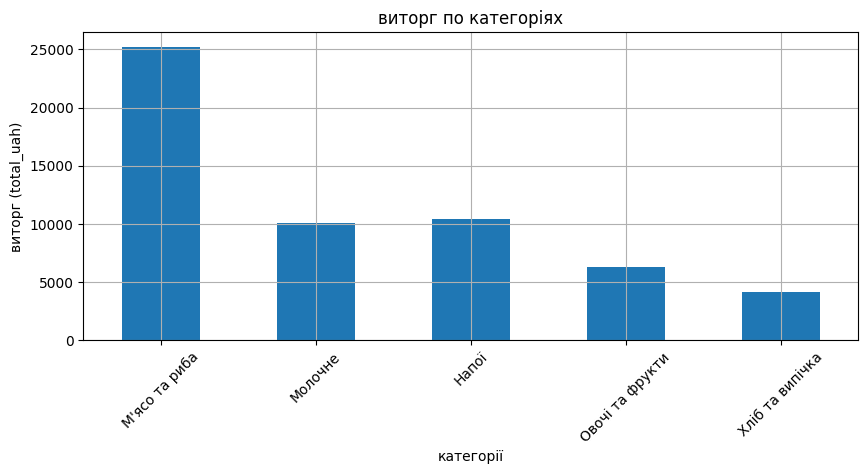

In [ ]:


fig = plt.figure(figsize=(10,4))
#df.category.value_counts().plot(kind='bar')
df.groupby('category')['total_eur'].sum().plot(kind='bar')
plt.title("Umsatz nach Kategorien")
plt.xlabel("Kategorien")
plt.ylabel("Umsatz (total_eur)")
plt.xticks(rotation=45)
plt.grid()
plt.show()




Horizontales Balkendiagramm - Top-10-Produkte nach Umsatz.


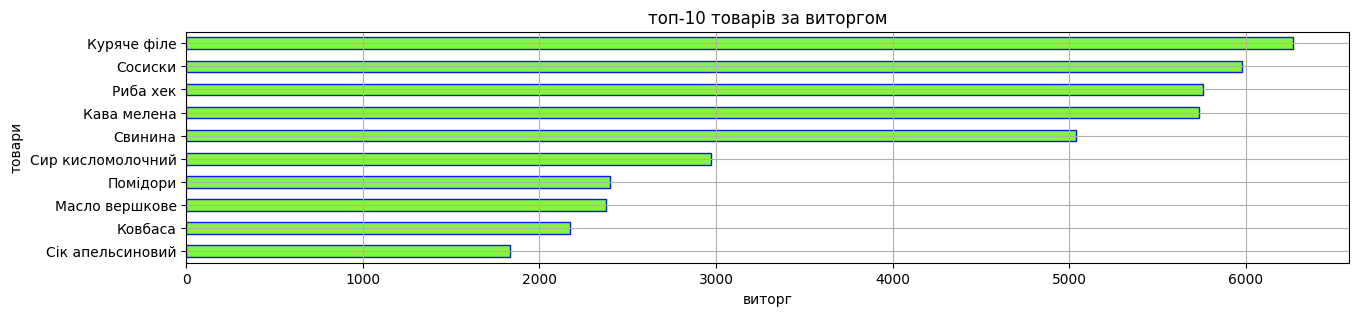

In [ ]:
fig = plt.figure(figsize=(15,3))

top10_revenue = (
    df.groupby("product")['total_eur']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

top10_revenue.plot(
    kind='barh',
    color='#84f542',
    edgecolor="#0d1ce0"
)

plt.title('Top-10-Produkte nach Umsatz')
plt.xlabel('Umsatz')
plt.ylabel('Produkte')
plt.grid()
plt.show()


Kreisdiagramm - Verteilung der Zahlungsmethoden.


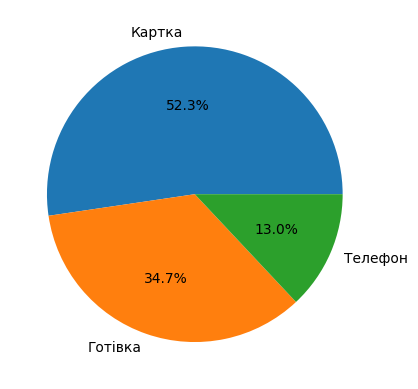

In [ ]:
fig = plt.figure()
payment_count = df.payment.value_counts()
plt.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')

plt.show()

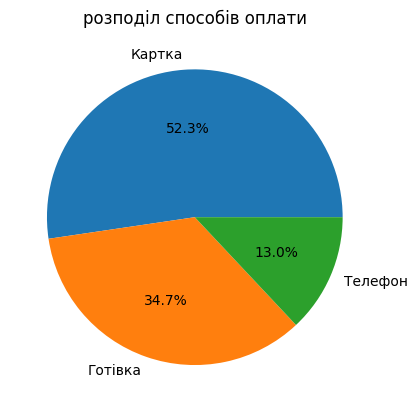

In [ ]:
fig, ax = plt.subplots()
payment_count = df.payment.value_counts()
ax.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
ax.set_title('Verteilung der Zahlungsmethoden')
plt.show()


Liniendiagramm - Umsatz nach Tagen im März.


<Axes: xlabel='day'>

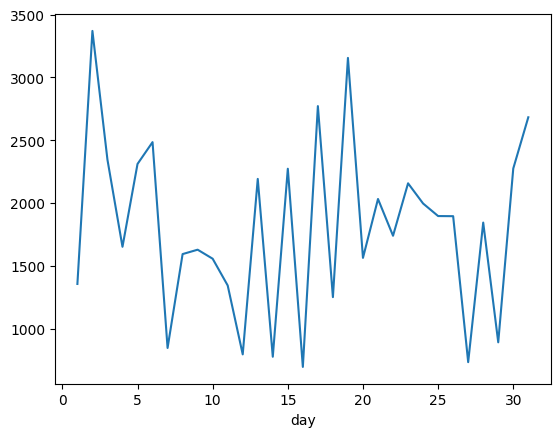

In [ ]:
df.groupby('day')['total_eur'].sum().plot(kind='line')

In [ ]:
df.groupby(['day','category'])['total_eur'].sum().unstack()

category,М'ясо та риба,Молочне,Напої,Овочі та фрукти,Хліб та випічка
day,,,,,
1,NaN,165.0,756.0,434.0,NaN
2,2209.0,255.0,375.0,472.0,60.0
3,1580.0,180.0,461.0,60.0,64.0
4,1320.0,114.0,162.0,NaN,55.0
5,630.0,305.0,811.0,175.0,390.0
6,1377.0,178.0,155.0,775.0,NaN
7,610.0,120.0,NaN,115.0,NaN
8,588.0,500.0,NaN,45.0,460.0
9,990.0,302.0,36.0,300.0,NaN


<Axes: xlabel='day'>

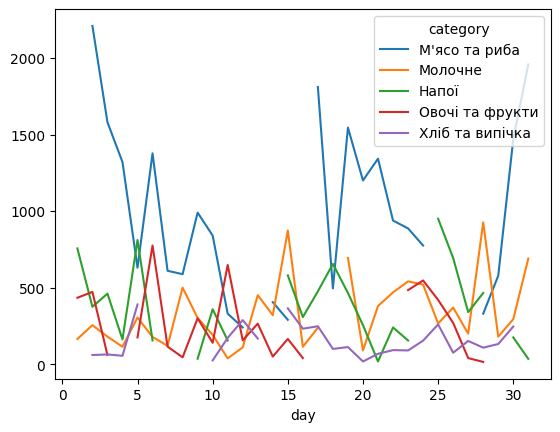

In [ ]:
df.groupby(['day','category'])['total_eur'].sum().unstack().plot()

Histogramm - Verteilung von customer_age.


In [ ]:
df.customer_age.value_counts()

,count
customer_age,
28,10
32,10
37,10
58,9
20,9
25,9
19,8
46,8
29,8


In [ ]:
df['customer_age'].value_counts().mean()

np.float64(5.882352941176471)

[22. 14. 25. 20. 21. 24. 17. 21. 17. 22. 23. 20. 18. 16. 20.]
[18.  21.4 24.8 28.2 31.6 35.  38.4 41.8 45.2 48.6 52.  55.4 58.8 62.2
 65.6 69. ]
<BarContainer object of 15 artists>


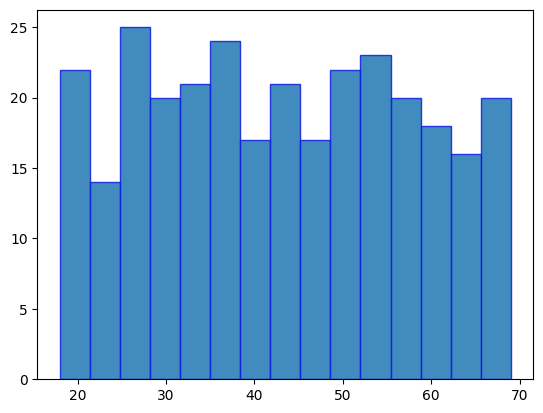

In [ ]:
counts, bins, patches =  plt.hist(
    df['customer_age'],
    bins=15,
    edgecolor='#0d1ce0',
    alpha=0.85
)

print(counts)
print(bins)
print(patches)


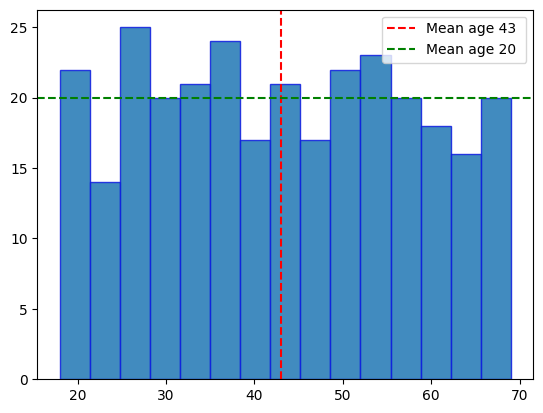

In [ ]:
from matplotlib.lines import lineStyles
plt.hist(
    df['customer_age'],
    bins=15,
    edgecolor='#0d1ce0',
    alpha=0.85

)
plt.axvline(
    df['customer_age'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean age {df['customer_age'].mean():.0f} "
)
plt.axhline(
    counts.mean(),
    color='green',
    linestyle='--',
    label=f"Mean age {counts.mean():.0f} "
)
plt.legend()
plt.show()

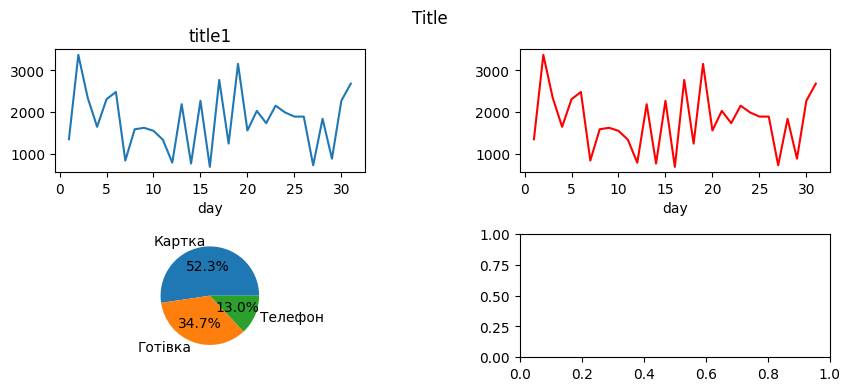

In [ ]:
# plt.figure(figsize=(8, 3))
fig, axes = plt.subplots(2, 2, figsize=(10, 4))
fig.suptitle("Title")
plt.subplots_adjust(hspace=0.5, wspace=0.5)

ax1 = axes[0, 0]
ax1.set_title("title1")
ax1.set_xlabel("bins age")
df.groupby('day')['total_eur'].sum().plot(kind='line', ax=ax1)
ax2 = axes[0, 1]
df.groupby('day')['total_eur'].sum().plot(kind='line', color="red", ax=ax2)
ax3 = axes[1, 0]
payment_count = df.payment.value_counts()
ax3.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
plt.savefig('figure.png')
plt.show()

Welche Produktkategorie ist am profitabelsten?   

Aus dem Histogramm des Umsatzes nach Kategorien sehen wir, dass die profitabelste Kategorie Fleisch und Fisch ist  

In welchen Stunden ist der Handel am aktivsten?
Um 14 und 13 Uhr findet der aktivste Handel statt, möglicherweise hängt das damit zusammen, dass Menschen in der Mittagspause einkaufen.  

Welche Zahlungsmethode überwiegt?  
Aus dem Diagramm sehen wir, dass die Zahlung per Karte überwiegt.  

Gibt es „Spitzentage" beim Verkauf?
Wer ist der typische Kunde (Alter, was er kauft, wie er bezahlt)?




In [ ]:
print(f"Alter:{df_origin['customer_age'].median():.0f} Jahre")
print(f"Lieblingsprodukt:{df_origin['product'].value_counts().index[0]}")
print(f"Zahlungsmethode:{df_origin['payment'].value_counts().index[0]}")
print(f"Durchschnittlicher Bon: {(df_origin['quantity'] * df_origin['price_eur']).mean():.2f}")


Вік:42 років
Улюблений товар:Кефір 0.5л
Спосіб оплати:Картка
Середній чек: 186.97
